### 一、部署在docker上，运行后得到web端

主界面：提问

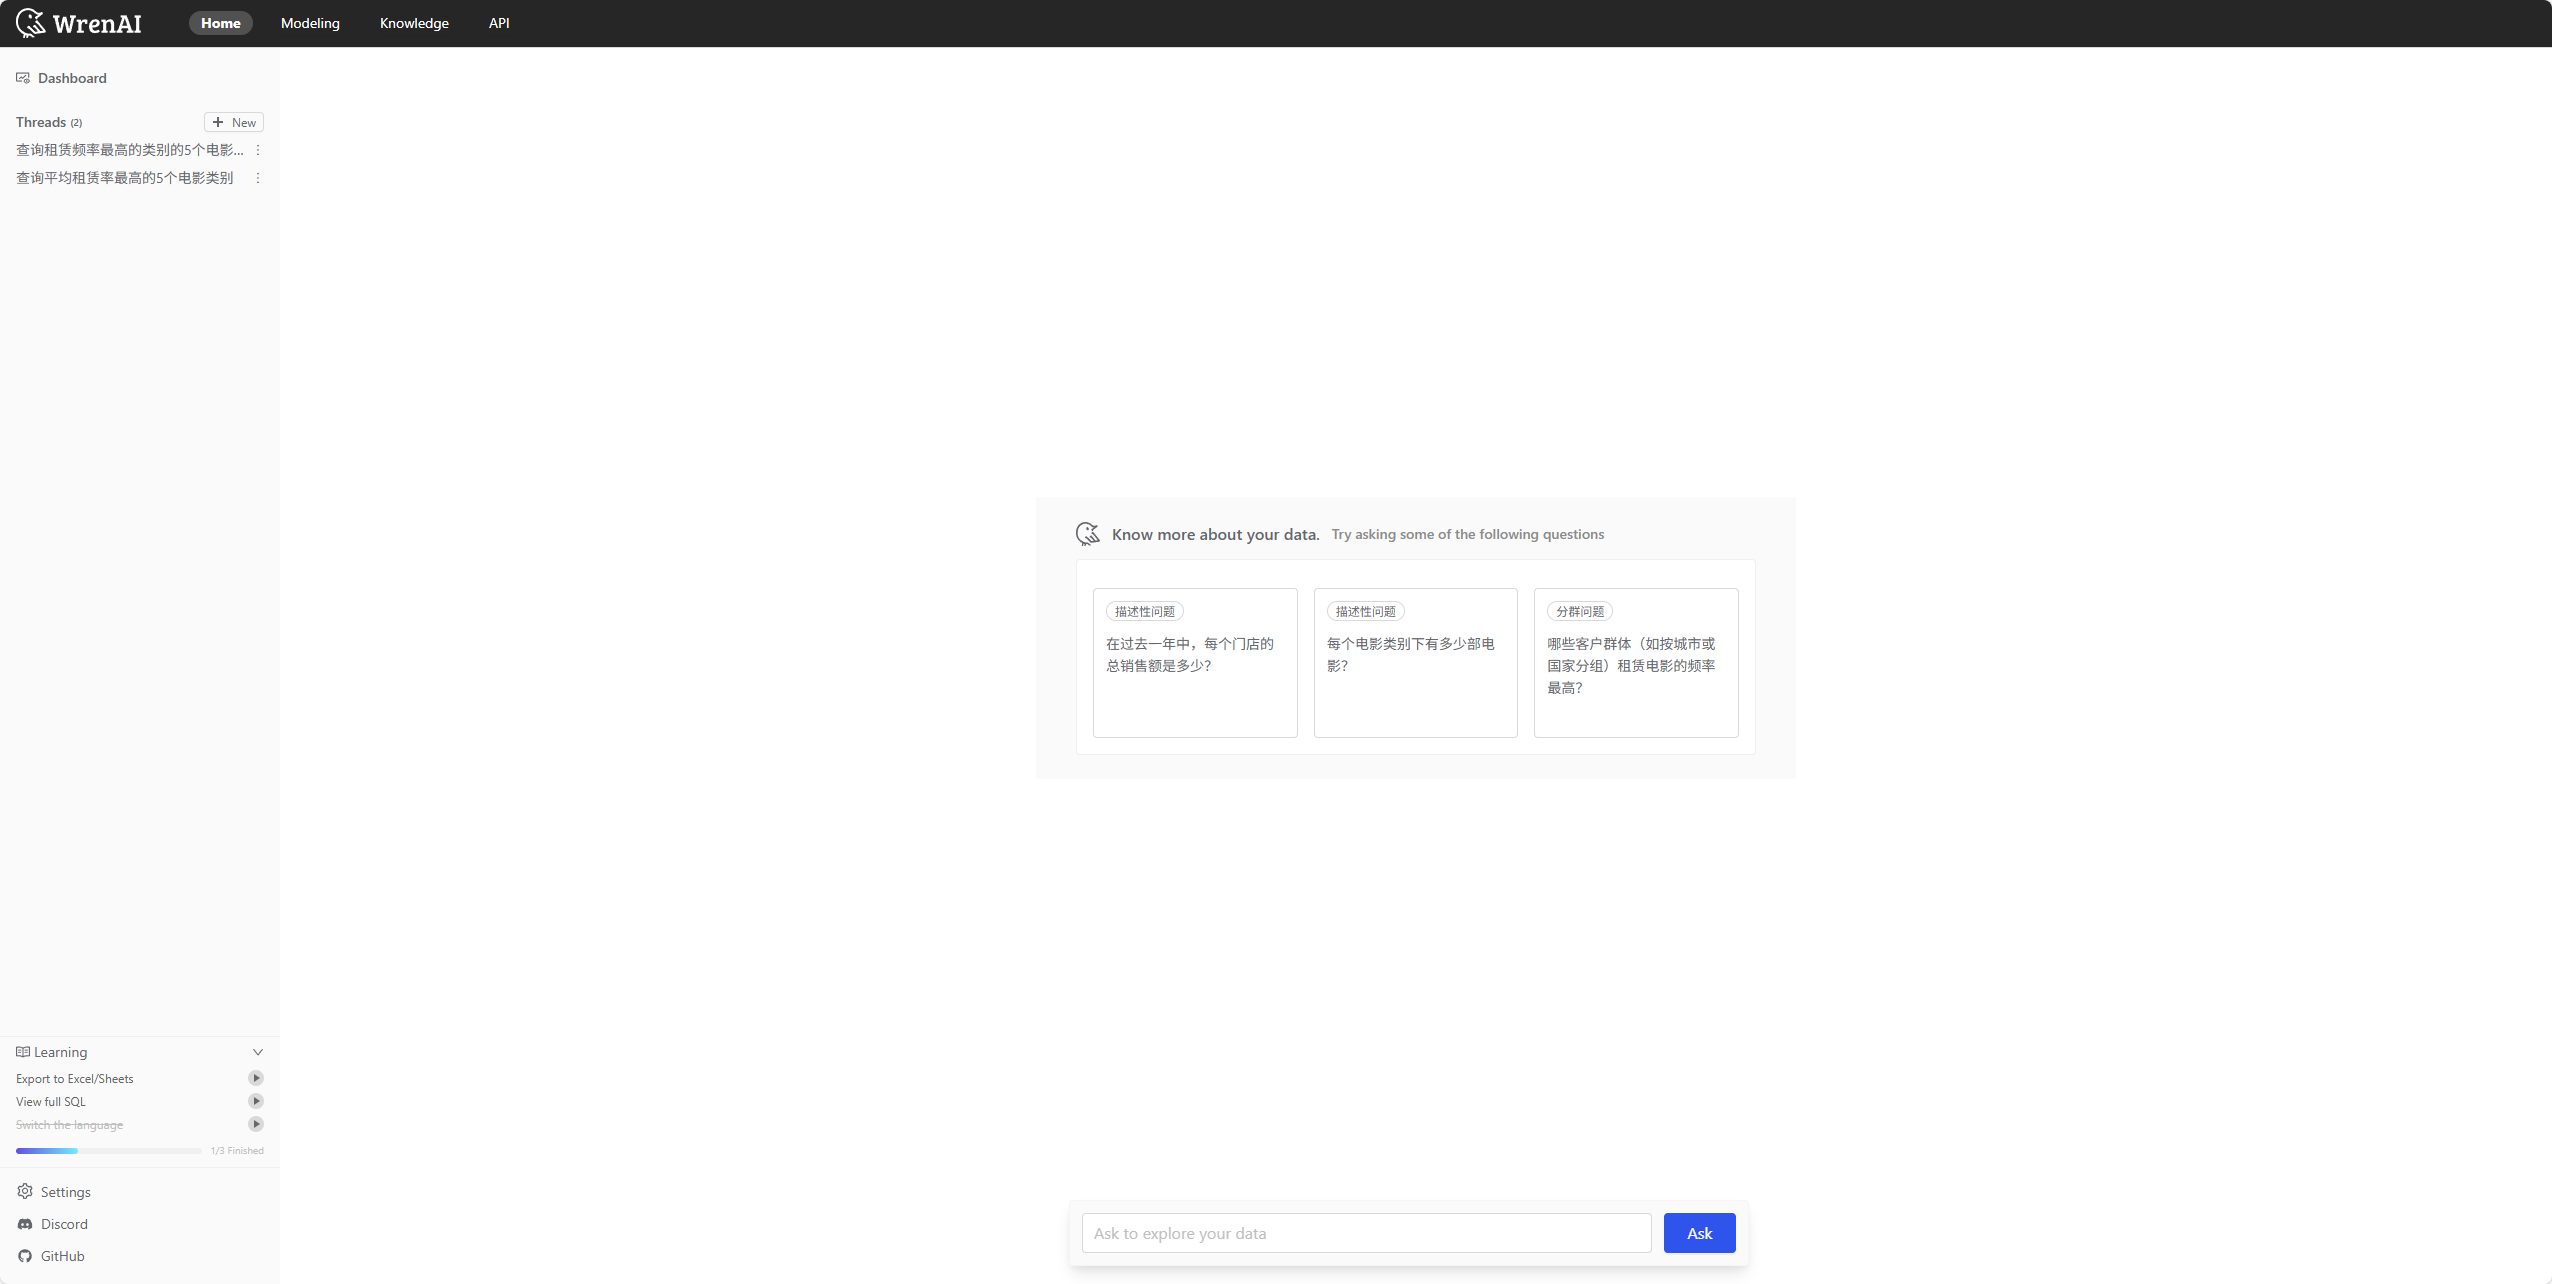

数据库页：展示数据库

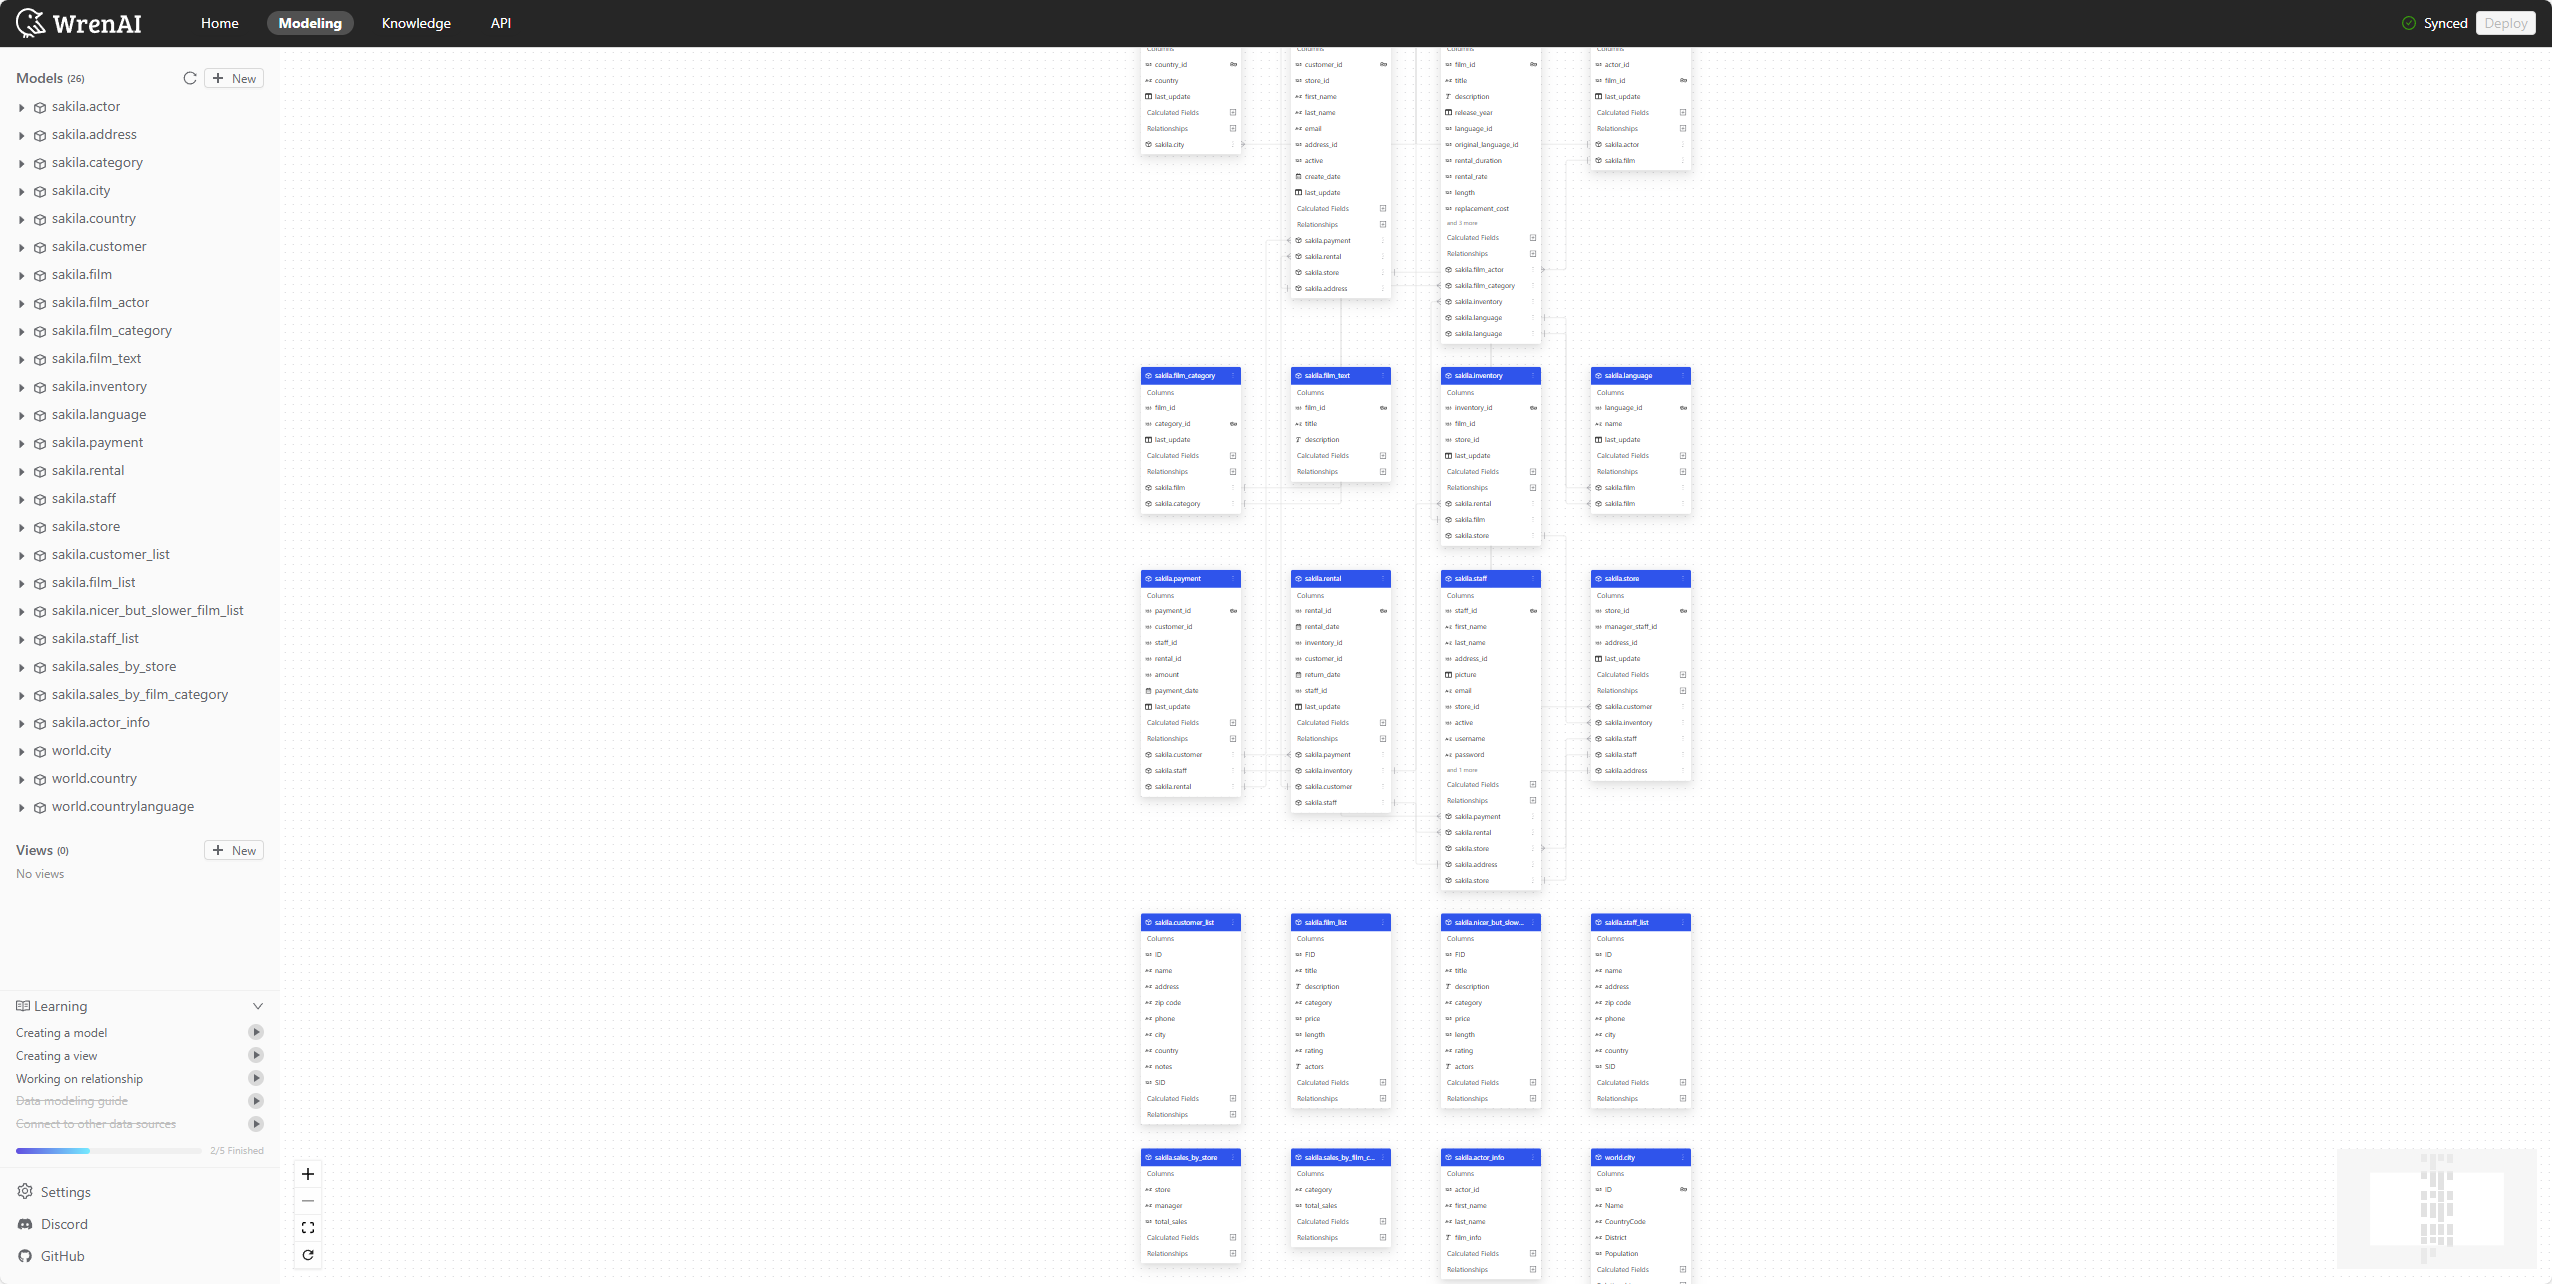

知识库：存储正确的Q-A对和数据库介绍

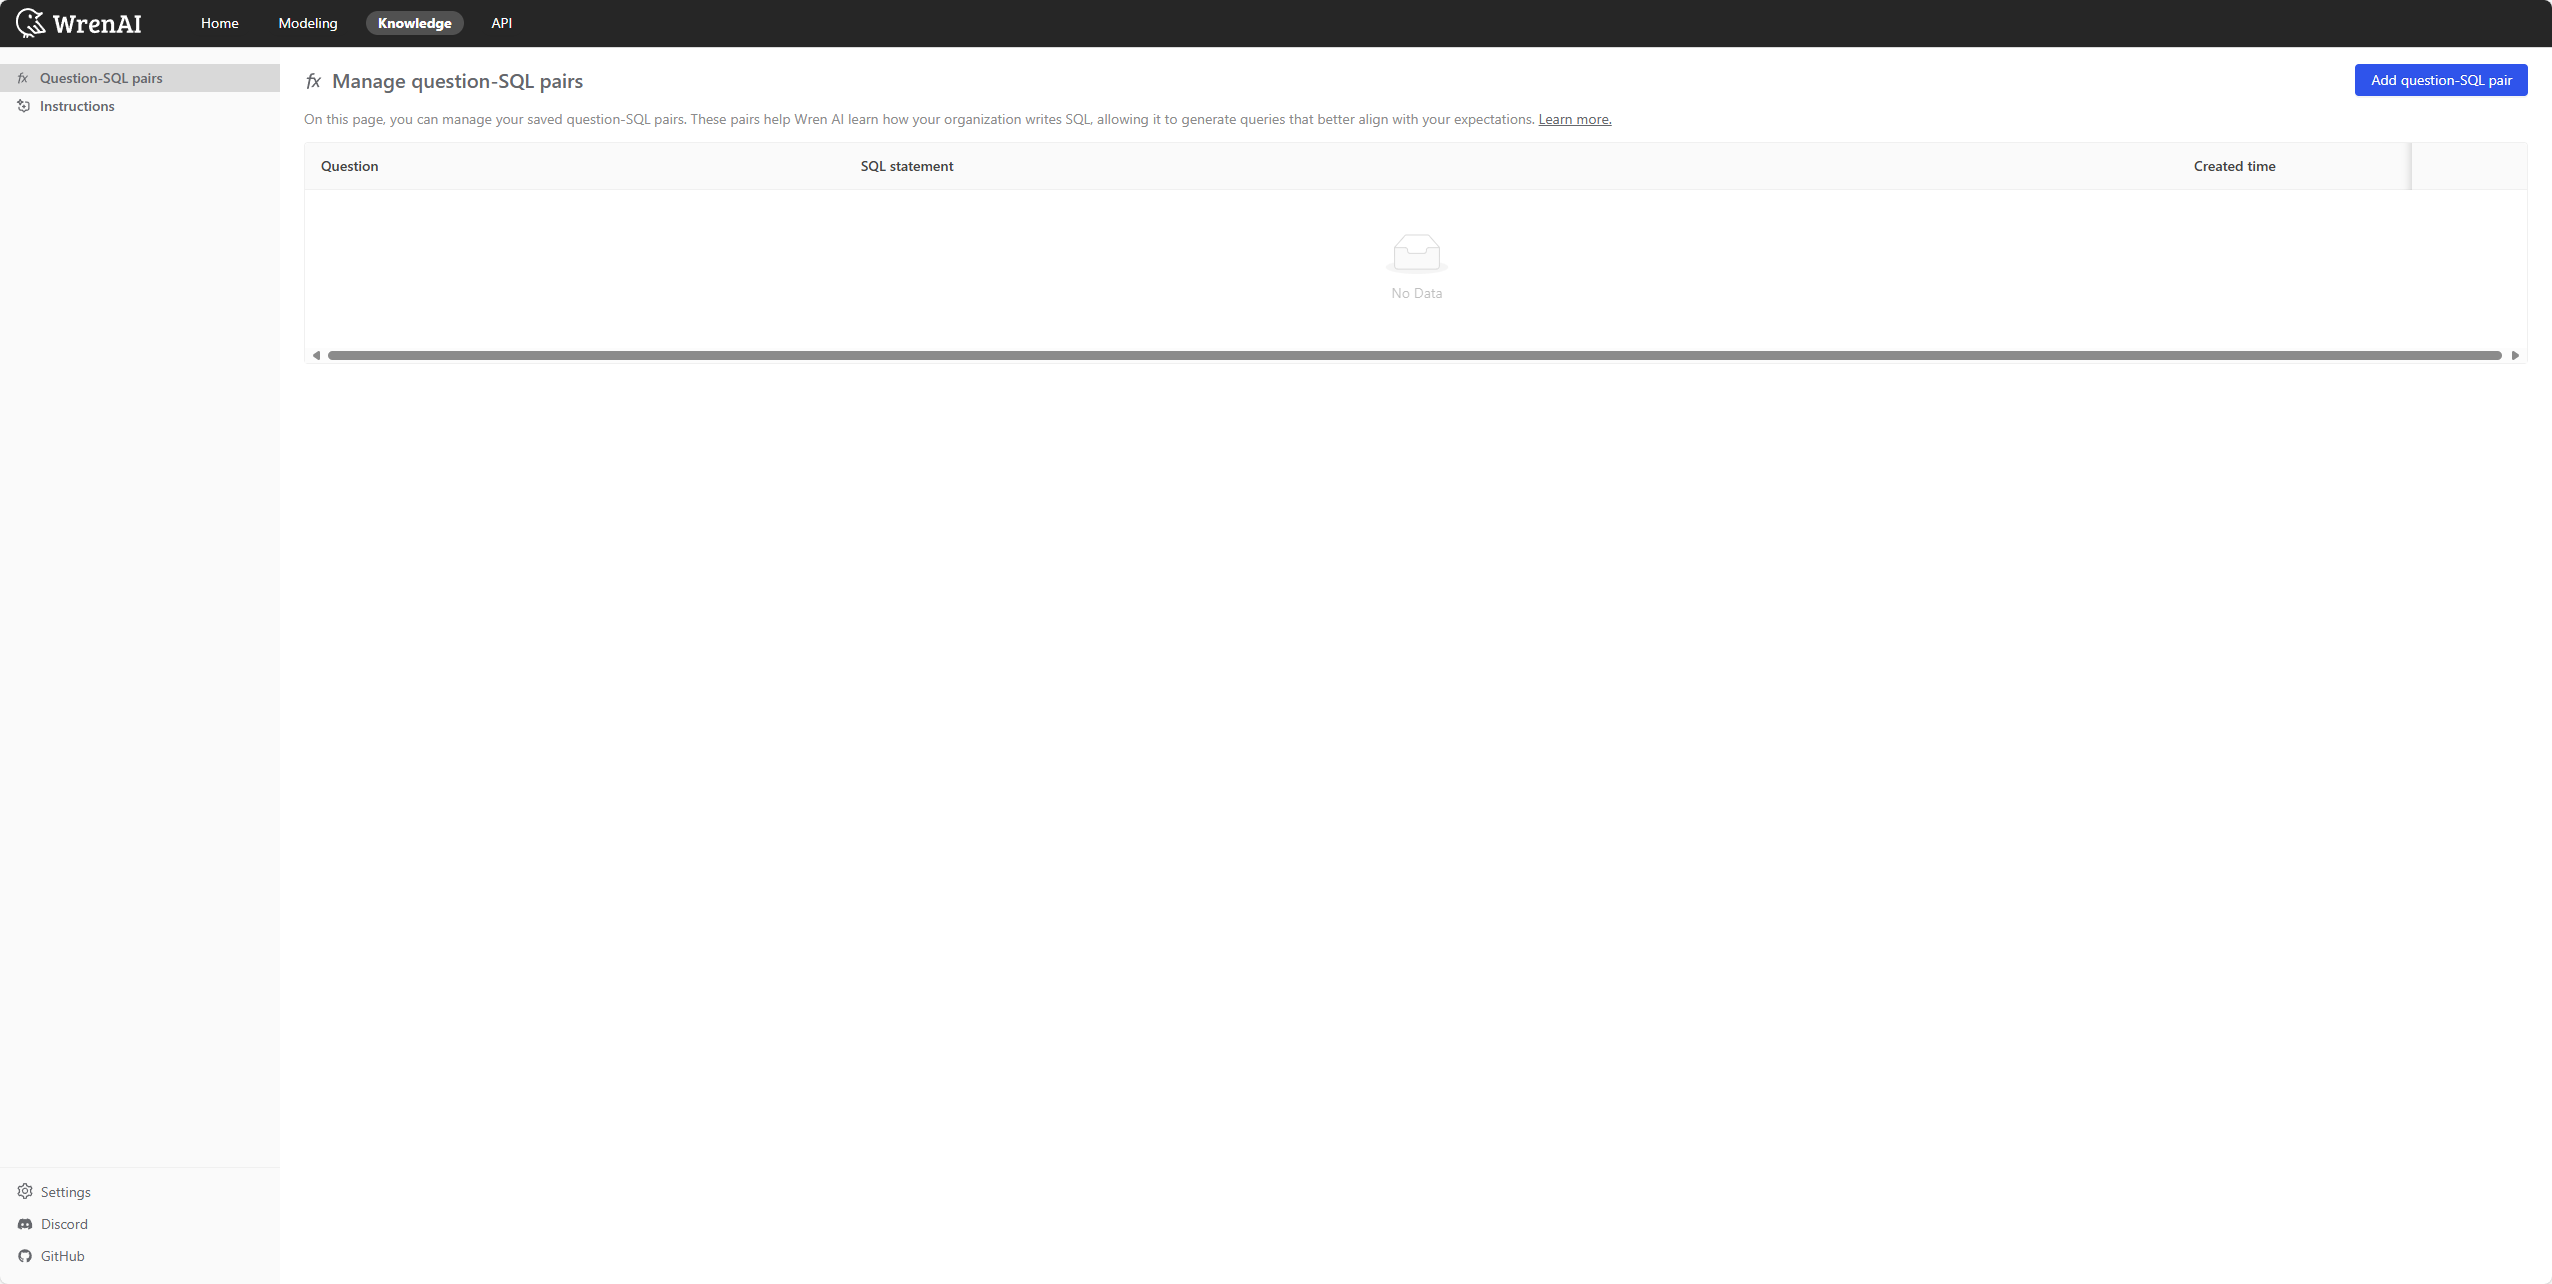

API：部署成功后，可以在网页之外调用api实现相同功能

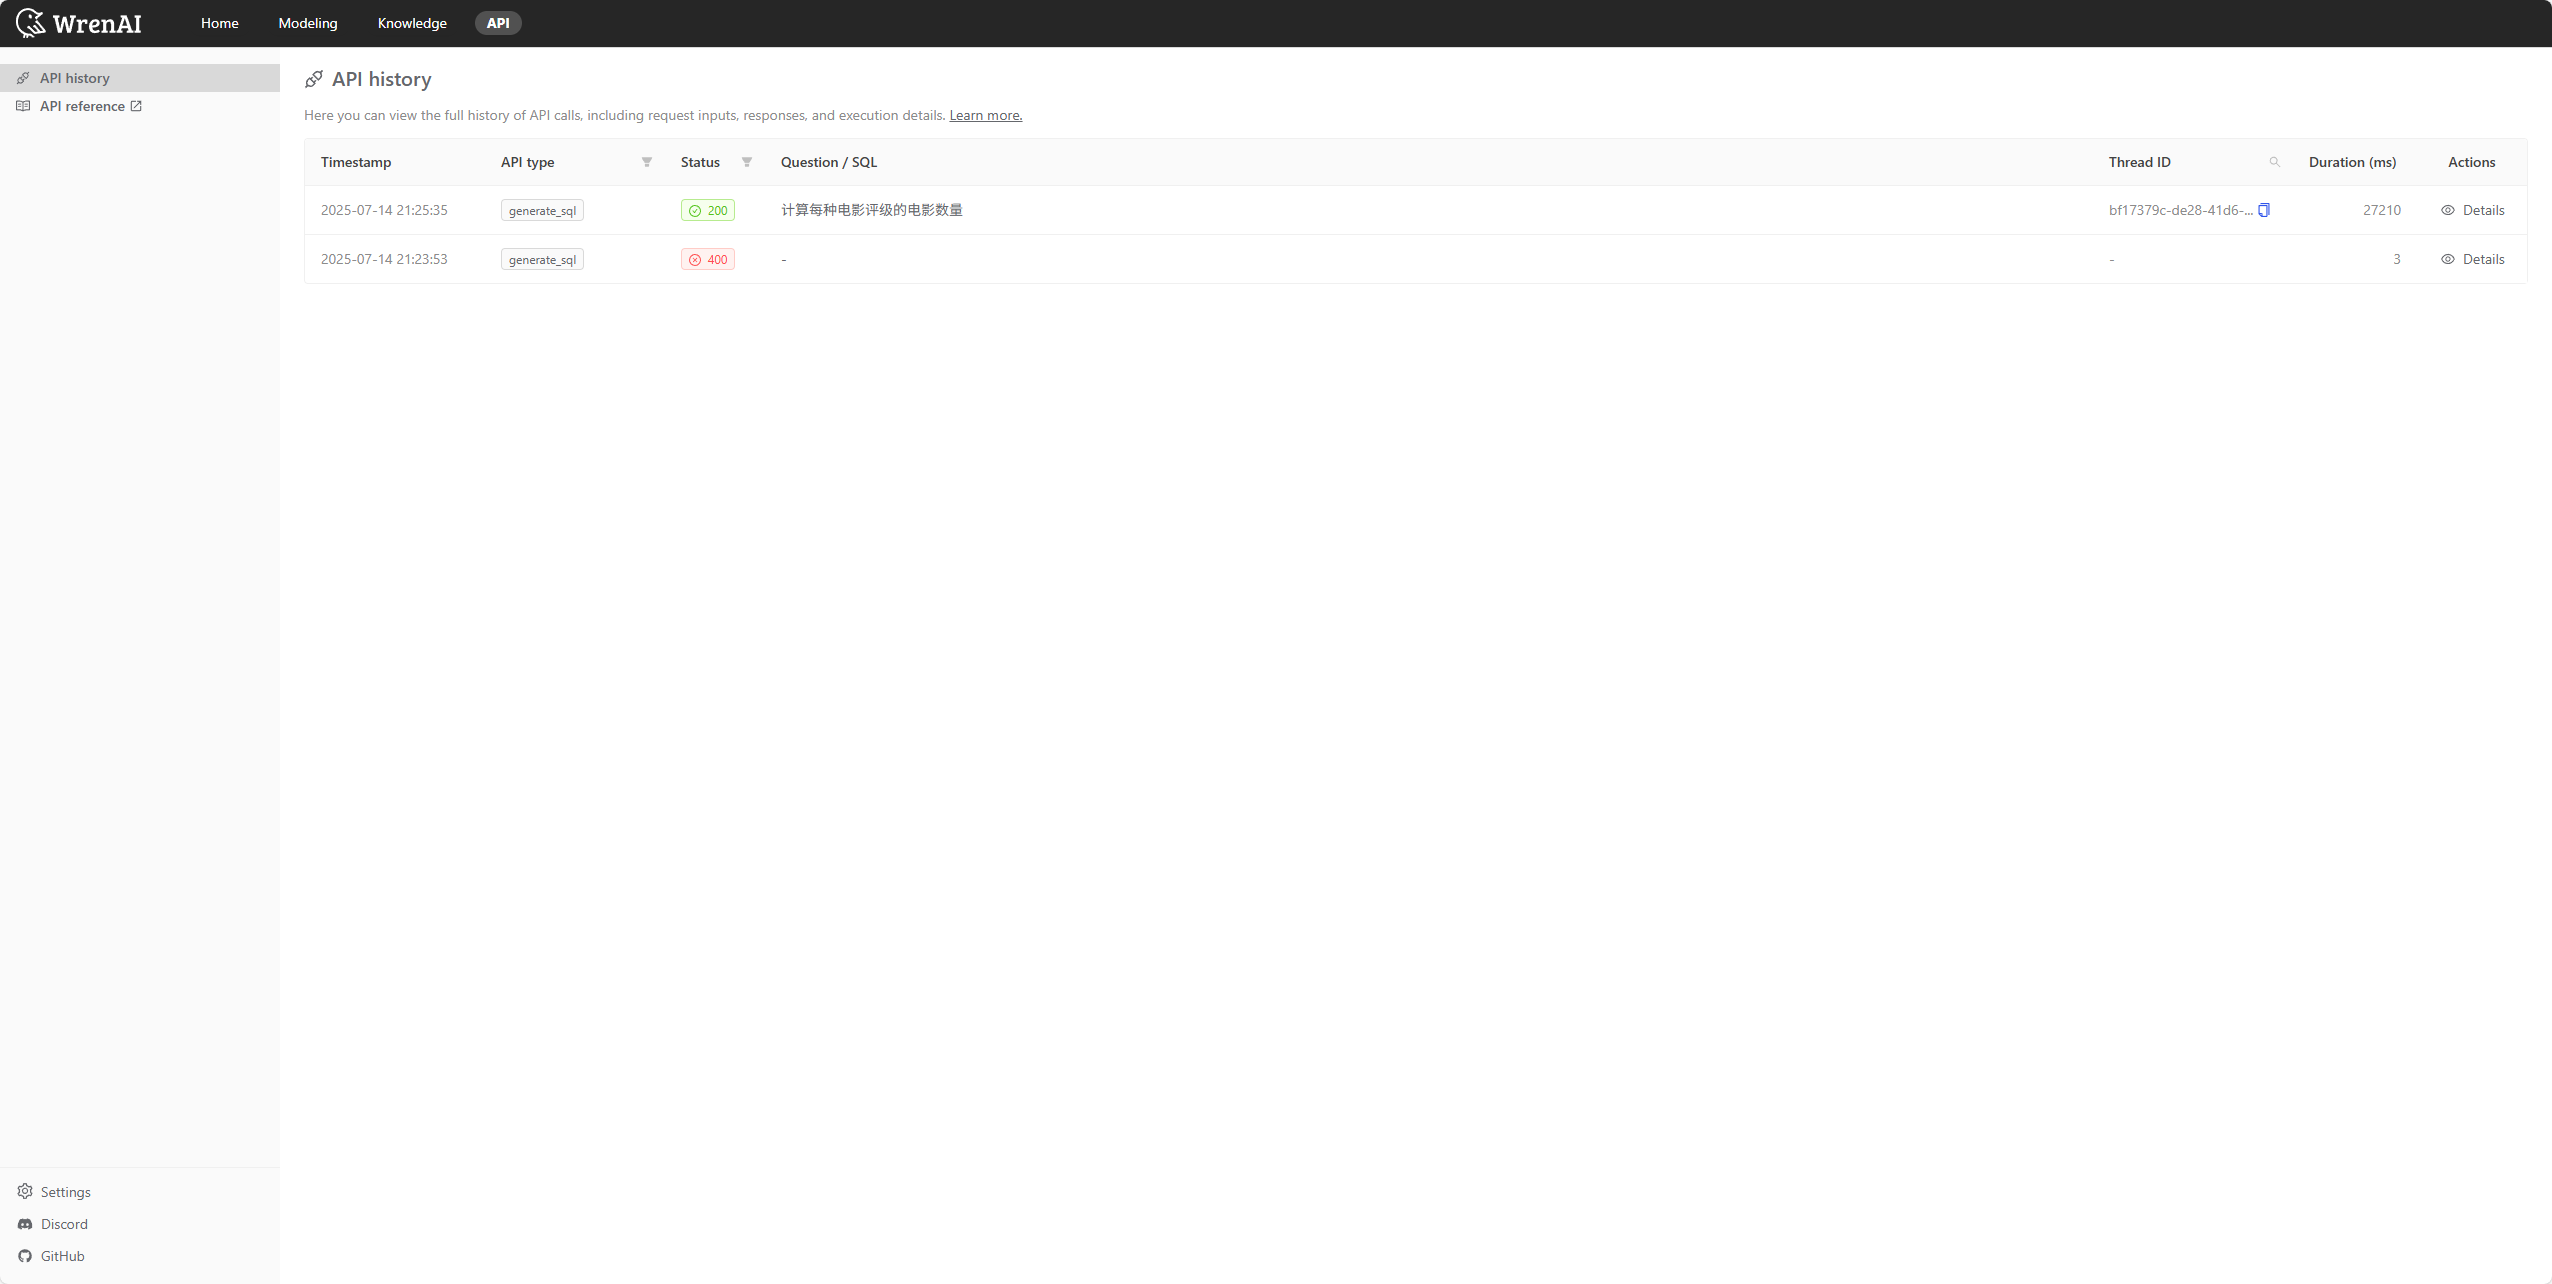

### 二、运行实例：

链接mysql的sakila数据库，提问：查询租赁频率最高的类别的5个电影类别。生成结果如下：

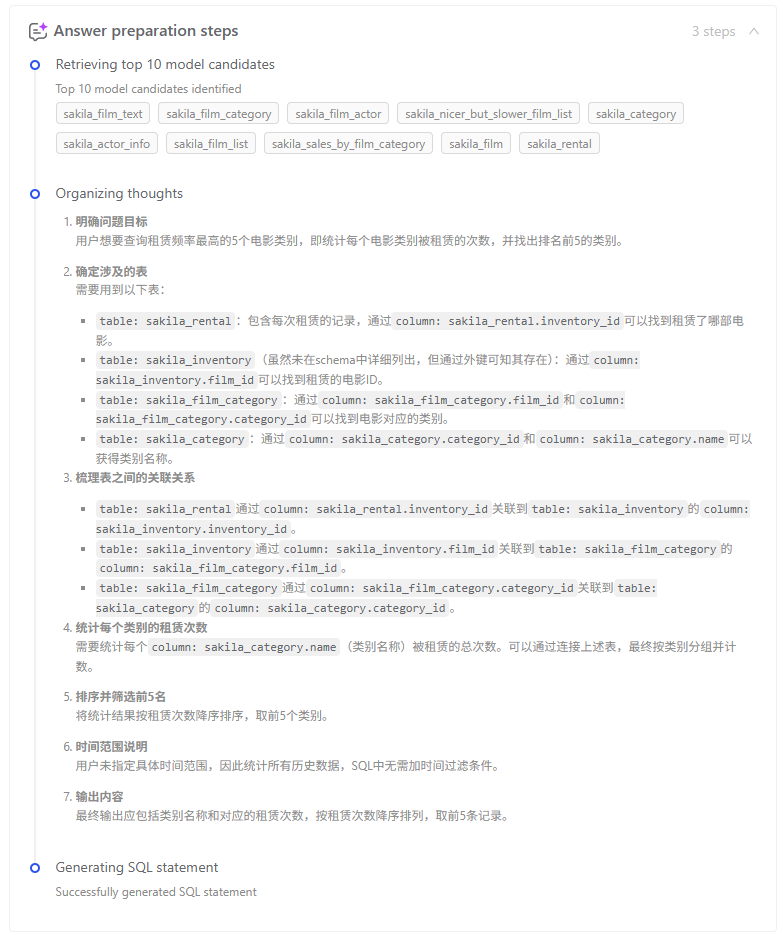
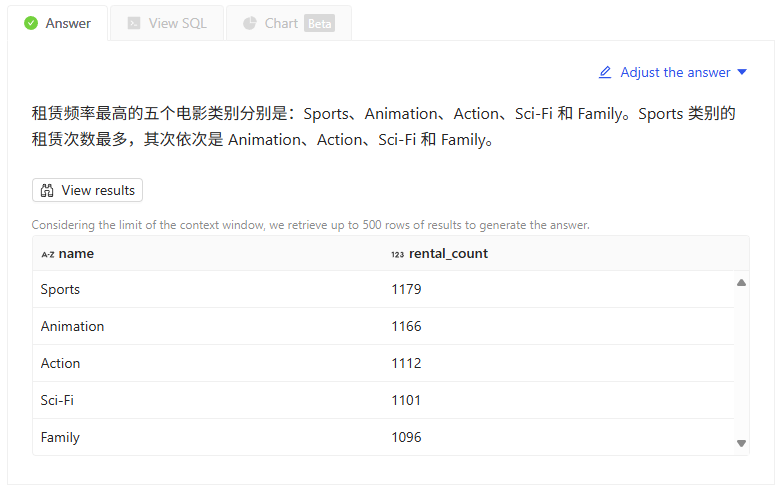

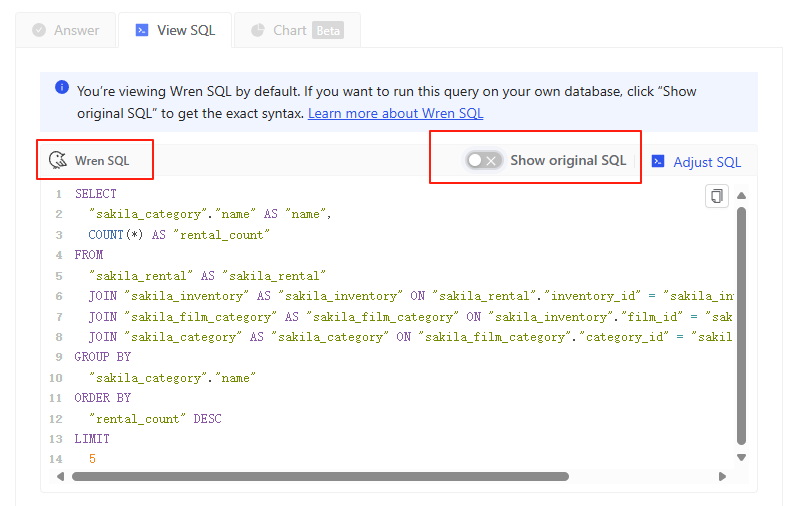
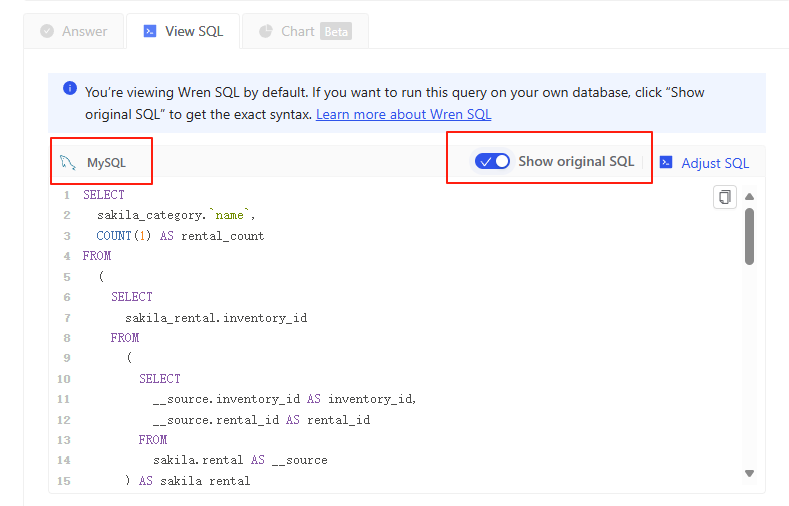

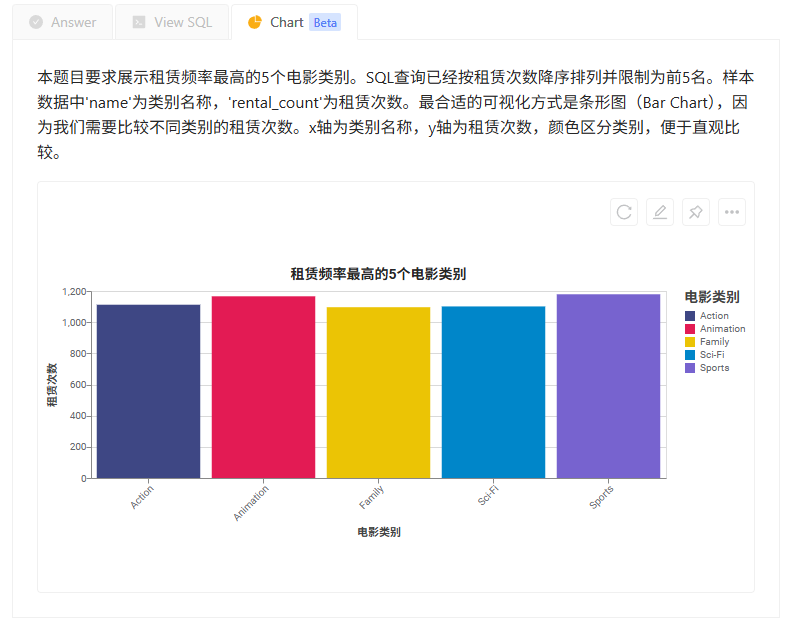

在 View SQL界面会提供两个SQL语句，一个是WrenAI自己定义的标准SQL语句，另一个是所连接数据库的SQL语句。实际上WrenAI调用大模型生成的是Wren SQL，再通过自己的Wren Core转化成对应数据库的SQL语言。（Wren SQL的格式在prompt中有规定）

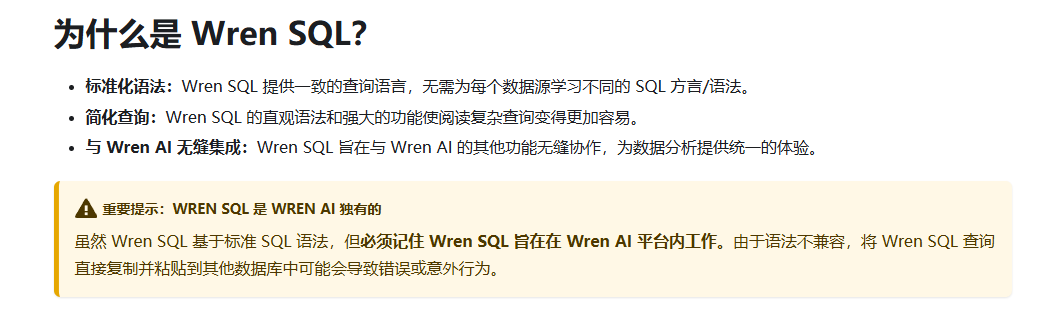

上述例子生成的SQL语句具体如下：



Wren SQL：
SELECT
  "sakila_category"."name" AS "name",
  COUNT(*) AS "rental_count"
FROM
  "sakila_rental" AS "sakila_rental"
  JOIN "sakila_inventory" AS "sakila_inventory" ON "sakila_rental"."inventory_id" = "sakila_inventory"."inventory_id"
  JOIN "sakila_film_category" AS "sakila_film_category" ON "sakila_inventory"."film_id" = "sakila_film_category"."film_id"
  JOIN "sakila_category" AS "sakila_category" ON "sakila_film_category"."category_id" = "sakila_category"."category_id"
GROUP BY
  "sakila_category"."name"
ORDER BY
  "rental_count" DESC
LIMIT
  5

因为sakila数据库是公开的比较出名的数据库，所以我尝试把相同问题直接丢给deepseek回答，得到如下SQL

二者在mysql中都能正常执行且结果相同。所以我认为所谓的Wren Core翻译SQL实际上效率应该不高，且比较死板。

### 三、Prompt如下，具体调用在所附的另一个py文件里。

中文翻译版本如下：

### 调用API（生成的SQL语句是Wren SQL格式）

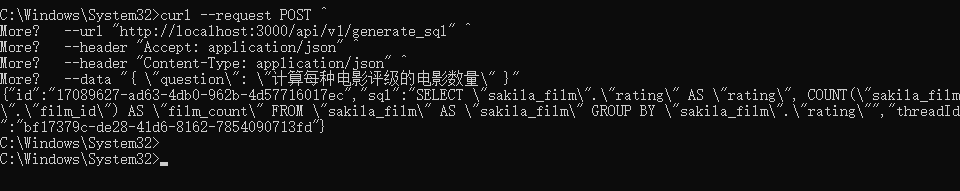